# 4. Magnetohydrodynamics in one dimension: waves, Riemann problems, and solvers

Ideal magnetohydrodynamics (MHD) adds a magnetic field to the Euler equations. The field is frozen
into the fluid, exerts a pressure and a tension, and brings new waves with it: instead of three wave
families there are seven. This notebook covers

1. the ideal MHD equations and the forces of the magnetic field;
2. the seven MHD waves and their speeds, checked numerically;
3. the MHD Riemann problem, which is considerably richer than the hydrodynamic one;
4. the Riemann solvers of Piastra's MHD module on the classic Brio–Wu and Ryu–Jones problems;
5. accuracy and dissipation on an exact nonlinear solution, the circularly polarized Alfvén wave.

In one dimension the divergence constraint $\nabla\cdot\mathbf{B} = 0$ is trivial; the next notebook is
devoted to it. The notebook assumes the two notebooks on gas dynamics.

In [1]:
import os, sys, io, contextlib
sys.path.insert(0, os.path.abspath('..'))          # the Piastra root directory

import numpy as np
import matplotlib.pyplot as plt

from src.parameters import Parameters
from src.grid.grid_setup import Grid
from src.sim_state import SimState
from src.misc.helpers import initial_model
from main import SOLVER_DISPATCH


def setup(problem, N, init=None, **options):
    '''Parameters, grid, state, EOS and solver for a 1D MHD problem of the catalogue.
    `init(grid, state, par, eos)`, if given, modifies the set-up before the solver is built.'''
    with contextlib.redirect_stdout(io.StringIO()):
        par = Parameters(mode="MHD", problem=problem, Nx1=N, Nx2=1, **options)
        grid = Grid(par.Nx1, par.Nx2, par.Ngc)
        state = SimState(grid, par)
        grid, state, par, eos = initial_model(grid, state, par)
        if init is not None:
            init(grid, state, par, eos)
        solver = SOLVER_DISPATCH["MHD"](grid, state, eos, par)
    return grid, state, par, eos, solver


def evolve(solver, par, t_end=None):
    '''Advance the solution to t_end (default: the final time of the problem).'''
    if t_end is not None:
        par.timefin = t_end
    with contextlib.redirect_stdout(io.StringIO()):
        while par.timenow < par.timefin - 1e-12:
            state = solver.step_RK()
    return state


def profile(grid, array):
    '''Cell centres and values along x1 (interior cells of a 1D run).'''
    g = grid.Ngc
    return grid.cx1[g:-g, g], array[g:-g, g].copy()

## 1. The ideal MHD equations

For a perfectly conducting fluid the electric field in the fluid frame vanishes,
$\mathbf{E} = -\mathbf{v}\times\mathbf{B}$, and Faraday's law becomes the **induction equation**. With
the magnetic field in units that absorb $\sqrt{4\pi}$, the conservation laws read

$$\begin{aligned}
&\partial_t \rho + \nabla\cdot(\rho\mathbf{v}) = 0,\\
&\partial_t(\rho\mathbf{v}) + \nabla\cdot\left[\rho\mathbf{v}\mathbf{v} + \left(p + \tfrac{B^2}{2}\right)\mathsf{I} - \mathbf{B}\mathbf{B}\right] = 0,\\
&\partial_t E + \nabla\cdot\left[\left(E + p + \tfrac{B^2}{2}\right)\mathbf{v} - (\mathbf{v}\cdot\mathbf{B})\mathbf{B}\right] = 0,\\
&\partial_t \mathbf{B} + \nabla\cdot(\mathbf{v}\mathbf{B} - \mathbf{B}\mathbf{v}) = 0,
\end{aligned}
\qquad E = \frac{\rho v^2}{2} + \frac{p}{\gamma - 1} + \frac{B^2}{2}.$$

The Lorentz force $(\nabla\times\mathbf{B})\times\mathbf{B} = -\nabla(B^2/2) + (\mathbf{B}\cdot\nabla)\mathbf{B}$
splits into a **magnetic pressure** $B^2/2$, which acts like a gas pressure perpendicular to the field,
and a **magnetic tension** $(\mathbf{B}\cdot\nabla)\mathbf{B}$, which tries to straighten curved field
lines. Their relative importance is measured by the plasma parameter $\beta = 2p/B^2$.

In one dimension all quantities depend only on $x$, and the condition $\nabla\cdot\mathbf{B} =
\partial B_x/\partial x = 0$ means that $B_x$ is simply a constant. The induction equation then
evolves only the transverse components $B_y$ and $B_z$, and the system has seven unknowns:
$(\rho, v_x, v_y, v_z, p, B_y, B_z)$.

## 2. Seven waves

Linearizing about a uniform state gives seven characteristic speeds along $x$:

$$v_x, \qquad v_x \pm c_a, \qquad v_x \pm c_f, \qquad v_x \pm c_s,$$

* the **entropy wave** ($v_x$), a density perturbation carried with the flow, as in hydrodynamics;
* two **Alfvén waves**, $c_a = |B_x|/\sqrt{\rho}$: transverse, incompressible oscillations of the field
  lines, driven by tension;
* two **fast** and two **slow magnetosonic waves**, compressive waves driven by gas and magnetic
  pressure together,
  $$c_{f,s}^2 = \frac12\left[a^2 + b^2 \pm \sqrt{(a^2 + b^2)^2 - 4 a^2 b_x^2}\right], \quad
    a^2 = \frac{\gamma p}{\rho}, \quad b^2 = \frac{B^2}{\rho}, \quad b_x^2 = \frac{B_x^2}{\rho}.$$

The speeds are ordered, $c_s \le c_a \le c_f$, but they can coincide: along the field the Alfvén wave
has the same speed as one of the magnetosonic waves, and perpendicular to it the slow and Alfvén
speeds vanish. The MHD system is therefore not **strictly** hyperbolic, which is the origin of many
of its numerical difficulties. The speeds as a function of the angle between the wave vector and the
field (the Friedrichs diagram):

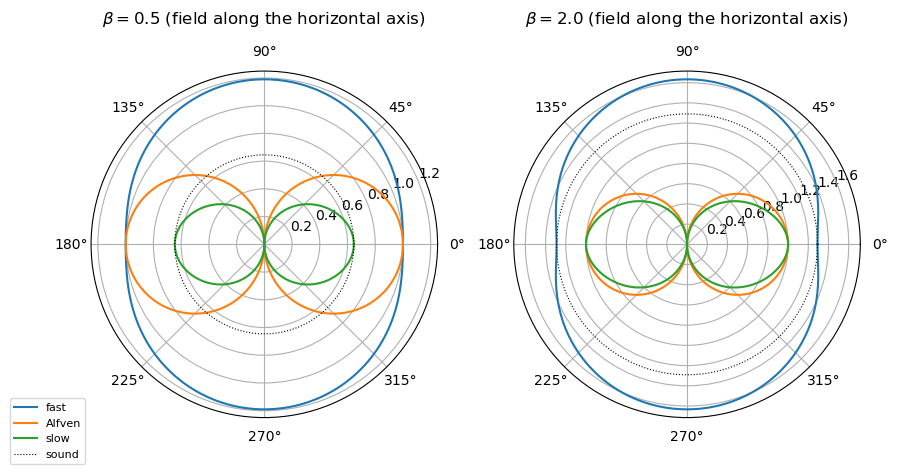

In [2]:
def mhd_speeds(rho, p, Bx, By, Bz, gamma):
    '''Alfven, fast and slow speeds along x.'''
    a2 = gamma * p / rho
    b2 = (Bx**2 + By**2 + Bz**2) / rho
    bx2 = Bx**2 / rho
    root = np.sqrt((a2 + b2)**2 - 4.0 * a2 * bx2)
    return np.sqrt(bx2), np.sqrt(0.5 * (a2 + b2 + root)), np.sqrt(np.maximum(0.5 * (a2 + b2 - root), 0.0))

angle = np.linspace(0.0, 2.0 * np.pi, 400)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), subplot_kw={'projection': 'polar'})
for ax, beta in zip(axes, [0.5, 2.0]):
    B = 1.0; p = 0.5 * beta * B**2                     # rho = 1, gamma = 5/3
    ca, cf, cs = mhd_speeds(1.0, p, B * np.cos(angle), B * np.sin(angle), 0.0, 5.0 / 3.0)
    ax.plot(angle, cf, label='fast'); ax.plot(angle, ca, label='Alfven'); ax.plot(angle, cs, label='slow')
    ax.plot(angle, np.full_like(angle, np.sqrt(5.0 / 3.0 * p)), 'k:', lw=0.8, label='sound')
    ax.set_title(rf'$\beta = {beta}$ (field along the horizontal axis)', pad=15)
axes[0].legend(loc='lower left', fontsize=8, bbox_to_anchor=(-0.25, -0.15))
plt.show()

We check these speeds with Piastra. In a uniform gas at rest with a field at 45° to the $x$-axis we
place two small Gaussian pulses: a compressive one (an isentropic perturbation of density and
pressure) and a transverse one (in $v_z$, perpendicular to the plane of the field). The compressive pulse
must split into fast and slow waves moving with $\pm c_f$ and $\pm c_s$; the transverse pulse into
Alfvén waves moving with $\pm c_a$. We build the state on the grid of the `alfven1D` problem:

c_a = 0.849, c_f = 1.448, c_s = 0.586, sound speed = 1.000


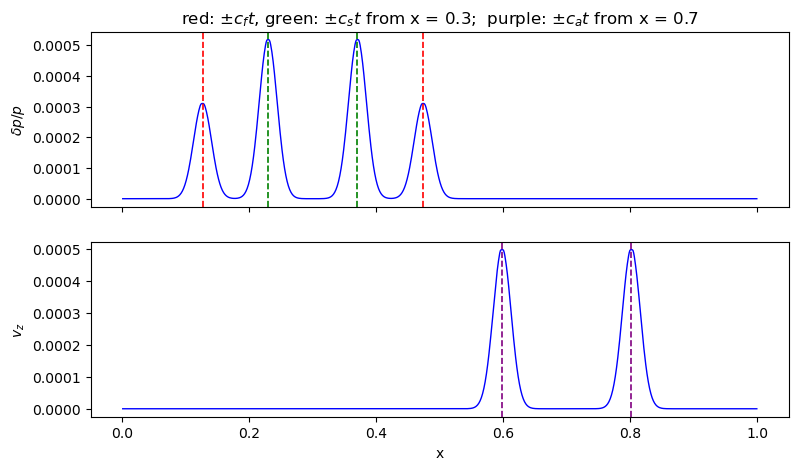

In [3]:
rho0, p0, B0, gamma = 1.0, 0.6, 1.2, 5.0 / 3.0
Bx0 = By0 = B0 / np.sqrt(2.0)
ca, cf, cs = mhd_speeds(rho0, p0, Bx0, By0, 0.0, gamma)
print(f"c_a = {ca:.3f}, c_f = {cf:.3f}, c_s = {cs:.3f}, sound speed = {np.sqrt(gamma * p0 / rho0):.3f}")

def two_pulses(grid, state, par, eos, amp=1e-3, w=0.02):
    x = grid.cx1
    bump_c = amp * np.exp(-((x - 0.3) / w)**2)            # compressive pulse at x = 0.3
    bump_t = amp * np.exp(-((x - 0.7) / w)**2)            # transverse pulse at x = 0.7
    state.dens[:, :] = rho0 * (1.0 + bump_c)
    state.pres[:, :] = p0 * (1.0 + gamma * bump_c)        # isentropic: dp/p = gamma drho/rho
    state.vel1[:, :] = 0.0; state.vel2[:, :] = 0.0
    state.vel3[:, :] = bump_t
    state.bfi1[:, :] = Bx0; state.bfi2[:, :] = By0; state.bfi3[:, :] = 0.0
    state.fb1[:, :] = Bx0; state.fb2[:, :] = By0

grid, state, par, eos, solver = setup("alfven1D", 1000, init=two_pulses, rec_type='PPM', RK_order='RK3',
                                       solver_type='HLLD', CFL=0.5)
t = 0.12
state = evolve(solver, par, t_end=t)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
x, dp = profile(grid, state.pres)
axes[0].plot(x, dp / p0 - 1.0, 'b-', lw=1)
for c, name in [(cf, 'fast'), (cs, 'slow')]:
    for sign in (-1, 1):
        axes[0].axvline(0.3 + sign * c * t, color='r' if name == 'fast' else 'g', ls='--', lw=1.2)
axes[0].set_ylabel(r'$\delta p / p$'); axes[0].set_title('red: $\\pm c_f t$, green: $\\pm c_s t$ from x = 0.3;  purple: $\\pm c_a t$ from x = 0.7')
x, vz = profile(grid, state.vel3)
axes[1].plot(x, vz, 'b-', lw=1)
for sign in (-1, 1):
    axes[1].axvline(0.7 + sign * ca * t, color='purple', ls='--', lw=1.2)
axes[1].set_ylabel('$v_z$'); axes[1].set_xlabel('x')
plt.show()

Each pulse has split into the expected waves, and they sit at the predicted positions. The transverse
velocity pulse excites only Alfvén waves: in this geometry they are decoupled from the compressive
waves, because $v_z$ and $B_z$ are perpendicular to the plane of the field.

## 3. The MHD Riemann problem

The solution of a Riemann problem in MHD contains up to seven waves: two fast waves (shocks or
rarefactions), two **rotational discontinuities** (Alfvén waves across which the transverse field
rotates while its magnitude stays the same), two slow waves, and a contact discontinuity. Two features
have no counterpart in hydrodynamics.

* Because the system is not strictly hyperbolic and not convex, **compound waves** — a shock and a
  rarefaction of the same family stuck together — can appear. Brio and Wu (1988) found one in the
  first MHD shock-tube simulation.
* The exact solution is complicated and, for some initial data, not unique. Piastra therefore has no
  exact MHD Riemann solver; reference solutions are computed on very fine grids.

The approximate Riemann solvers of the MHD module are the same ladder as in hydrodynamics, with one
more rung:

* **LLF** and **HLL**: one or two waves — robust and dissipative;
* **HLLC**: adds the contact discontinuity;
* **HLLD** (Miyoshi & Kusano 2005): four intermediate states separated by the fast waves, the two
  rotational discontinuities, and the contact; it resolves every discontinuity except the slow waves
  exactly for isolated waves and is the solver of choice for MHD.

## 4. The Brio–Wu shock tube

The Brio–Wu problem ($\gamma = 2$, $B_x = 0.75$, $B_y$ changing sign from $+1$ to $-1$) produces, from
left to right: a fast rarefaction, a **compound wave** (a slow shock attached to a slow rarefaction), a
contact discontinuity, a slow shock, and a fast rarefaction.

LLF  : L1 error of density against the reference 0.0053
HLL  : L1 error of density against the reference 0.0047
HLLC : L1 error of density against the reference 0.0038
HLLD : L1 error of density against the reference 0.0033


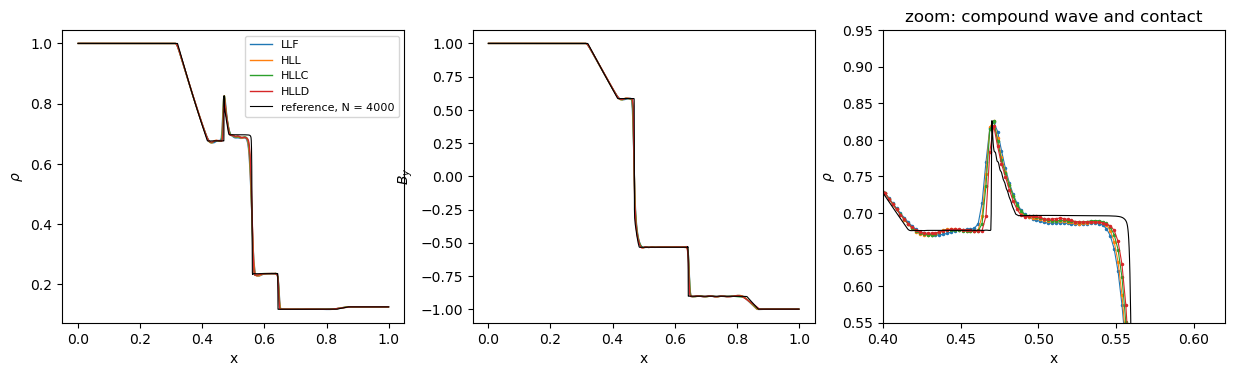

In [4]:
grid, state, par, eos, solver = setup("BW1D", 4000, rec_type='PLM', RK_order='RK2', solver_type='HLLD', CFL=0.5)
state = evolve(solver, par)
x_ref, rho_ref = profile(grid, state.dens)
x_ref, by_ref = profile(grid, state.bfi2)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for s in ['LLF', 'HLL', 'HLLC', 'HLLD']:
    grid, state, par, eos, solver = setup("BW1D", 400, rec_type='PLM', RK_order='RK2', solver_type=s, CFL=0.5)
    state = evolve(solver, par)
    x, rho = profile(grid, state.dens)
    x, by = profile(grid, state.bfi2)
    axes[0].plot(x, rho, lw=1, label=s); axes[1].plot(x, by, lw=1, label=s); axes[2].plot(x, rho, '.-', ms=3, lw=0.8, label=s)
    print(f"{s:5s}: L1 error of density against the reference {np.mean(np.abs(rho - np.interp(x, x_ref, rho_ref))):.4f}")
for ax, f in zip(axes, [rho_ref, by_ref, rho_ref]):
    ax.plot(x_ref, f, 'k-', lw=0.8, label='reference, N = 4000'); ax.set_xlabel('x')
axes[0].set_ylabel(r'$\rho$'); axes[1].set_ylabel('$B_y$'); axes[2].set_ylabel(r'$\rho$')
axes[2].set_xlim(0.4, 0.62); axes[2].set_ylim(0.55, 0.95); axes[2].set_title('zoom: compound wave and contact')
axes[0].legend(fontsize=8)
plt.show()

All solvers capture the wave pattern, including the compound wave, but with visibly different
sharpness. The contact discontinuity at $x \approx 0.55$ is where the solvers differ most: LLF and HLL
do not contain it in their wave model, HLLC and HLLD do.

## 5. The Ryu–Jones problem 2a: all seven waves

In the problem of Ryu & Jones (1995, test 2a) all three velocity components and both transverse field
components are nonzero, and the solution contains all seven waves: fast shocks, rotational
discontinuities, slow shocks, and the contact. The rotational discontinuities are best seen in the
angle of the transverse field, $\psi = \arctan(B_z/B_y)$, which jumps across them while
$|B_\perp|$ does not.

LLF  : the left rotational discontinuity is spread over 8 cells
HLLD : the left rotational discontinuity is spread over 3 cells


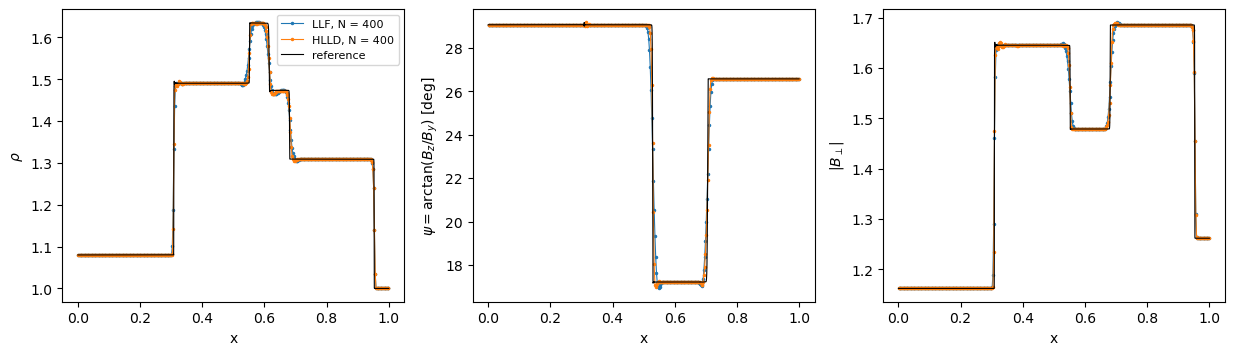

In [5]:
grid, state, par, eos, solver = setup("RJ1D", 4000, rec_type='PLM', RK_order='RK2', solver_type='HLLD', CFL=0.5)
state = evolve(solver, par)
x_ref = profile(grid, state.dens)[0]
ref = {k: profile(grid, getattr(state, k))[1] for k in ['dens', 'bfi2', 'bfi3']}

def jump_width(x, f, x1, x2):
    '''Number of cells in which f lies between 10% and 90% of its jump on [x1, x2].'''
    m = (x > x1) & (x < x2)
    lo, hi = f[m].min(), f[m].max()
    return int(np.sum((f[m] > lo + 0.1 * (hi - lo)) & (f[m] < hi - 0.1 * (hi - lo))))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for s in ['LLF', 'HLLD']:
    grid, state, par, eos, solver = setup("RJ1D", 400, rec_type='PLM', RK_order='RK2', solver_type=s, CFL=0.5)
    state = evolve(solver, par)
    x, rho = profile(grid, state.dens)
    by, bz = profile(grid, state.bfi2)[1], profile(grid, state.bfi3)[1]
    print(f"{s:5s}: the left rotational discontinuity is spread over "
          f"{jump_width(x, np.degrees(np.arctan2(bz, by)), 0.45, 0.6)} cells")
    axes[0].plot(x, rho, '.-', ms=3, lw=0.8, label=f'{s}, N = 400')
    axes[1].plot(x, np.degrees(np.arctan2(bz, by)), '.-', ms=3, lw=0.8, label=s)
    axes[2].plot(x, np.hypot(by, bz), '.-', ms=3, lw=0.8, label=s)
axes[0].plot(x_ref, ref['dens'], 'k-', lw=0.8, label='reference')
axes[1].plot(x_ref, np.degrees(np.arctan2(ref['bfi3'], ref['bfi2'])), 'k-', lw=0.8)
axes[2].plot(x_ref, np.hypot(ref['bfi2'], ref['bfi3']), 'k-', lw=0.8)
axes[0].set_ylabel(r'$\rho$'); axes[1].set_ylabel(r'$\psi = \arctan(B_z/B_y)$ [deg]'); axes[2].set_ylabel(r'$|B_\perp|$')
for ax in axes:
    ax.set_xlabel('x')
axes[0].legend(fontsize=8)
plt.show()

Reading the density from left to right: fast shock, rotational discontinuity (visible in $\psi$ only),
slow shock, contact, slow shock, rotational discontinuity, fast shock. At this resolution both solvers
capture all seven waves, but HLLD spreads the rotational discontinuity over about three cells and LLF,
which damps every wave with the fast speed, over about eight; with the first-order scheme the
difference is larger still (exercise 3). Rotational discontinuities, like contacts, are not steepened
by the flow, so this numerical spreading is never undone; in multidimensional problems it
accumulates, which is why HLLD is the default of the MHD module.

## 6. Accuracy and dissipation: the circularly polarized Alfvén wave

A circularly polarized Alfvén wave of any amplitude is an exact nonlinear solution of ideal MHD: the
transverse field rotates, the magnitude of the field and the total pressure stay constant, and the
wave propagates at $c_a = B_x/\sqrt{\rho}$ without change of shape. The problem `alfven1D` runs it for
one period, after which the exact solution equals the initial state. We use it to measure the
convergence of the scheme and to compare the dissipation of LLF and HLLD.

scheme           L1 errors of B_y for N = [32, 64, 128, 256]   -> orders
PCM + LLF        2.10e-02  1.15e-02  5.98e-03  3.06e-03   -> 0.88  0.94  0.97
PCM + HLLD       2.09e-02  1.14e-02  5.93e-03  3.03e-03   -> 0.88  0.94  0.97
PLM + LLF        3.44e-03  9.61e-04  2.44e-04  5.96e-05   -> 1.84  1.98  2.03
PLM + HLLD       3.43e-03  9.58e-04  2.43e-04  5.94e-05   -> 1.84  1.98  2.03
PPM + HLLD       7.28e-04  1.37e-04  2.54e-05  4.47e-06   -> 2.41  2.43  2.50
MP5 + HLLD       7.62e-06  8.10e-07  9.82e-08  1.23e-08   -> 3.23  3.04  3.00


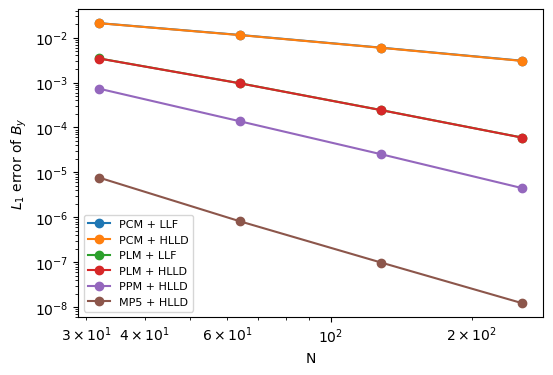

In [6]:
Ns = [32, 64, 128, 256]
print(f"{'scheme':16s} L1 errors of B_y for N = {Ns}   -> orders")
fig, ax = plt.subplots(figsize=(6, 4))
for rec, rk, s in [('PCM', 'RK1', 'LLF'), ('PCM', 'RK1', 'HLLD'), ('PLM', 'RK2', 'LLF'),
                   ('PLM', 'RK2', 'HLLD'), ('PPM', 'RK3', 'HLLD'), ('MP5', 'RK3', 'HLLD')]:
    e = []
    for N in Ns:
        grid, state, par, eos, solver = setup("alfven1D", N, rec_type=rec, RK_order=rk, solver_type=s, CFL=0.4)
        by0 = profile(grid, state.bfi2)[1]
        state = evolve(solver, par)
        e.append(np.mean(np.abs(profile(grid, state.bfi2)[1] - by0)))
    ax.loglog(Ns, e, 'o-', label=f'{rec} + {s}')
    print(f"{rec + ' + ' + s:16s}", "  ".join(f"{v:.2e}" for v in e), "  ->",
          "  ".join(f"{np.log2(e[i] / e[i + 1]):.2f}" for i in range(len(e) - 1)))
ax.set_xlabel('N'); ax.set_ylabel(r'$L_1$ error of $B_y$'); ax.legend(fontsize=8)
plt.show()

The Riemann solver makes no difference here, not even with the first-order scheme, and the reason
is instructive. The field is almost aligned with $x$ and $\beta = 0.2$, so along $x$ the fast speed is
practically equal to the Alfvén speed: the single wave speed of LLF *is* the speed of this wave, and
LLF is as accurate as HLLD. The advantage of HLLD appears when the fast speed is much larger than the
speed of the wave being resolved — as for the rotational discontinuities of the Ryu–Jones problem (3
cells with HLLD, 8 with LLF) or for contacts and slow waves in general.

The reconstruction, on the other hand, matters a lot: PCM converges at first order, PLM at second, and
PPM and MP5 reduce the error further; MP5 settles at third order, the order of the time integrator.